In [24]:
# GAN for 1D Distribution Fitting
# 用 GAN 拟合一维函数 / 概率分布
# 黄色柱状图 = 真实分布 p_data(x), 蓝色柱状图 = 生成器 G(z) 产生的分布 p_g(x)
# GAN 的目标：让 p_g(x) 逐渐接近 p_data(x)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

np.random.seed(42)

In [25]:
def sample_real_distribution(n):
    """
    真实分布（黄色）：
    混合两个高斯分布，形成双峰
    """
    choose_left = np.random.rand(n) < 0.5
    x = np.where(
        choose_left,
        np.random.normal(loc=-2.0, scale=0.7, size=n),
        np.random.normal(loc=1.0, scale=0.8, size=n)
    )
    return x.reshape(-1, 1)

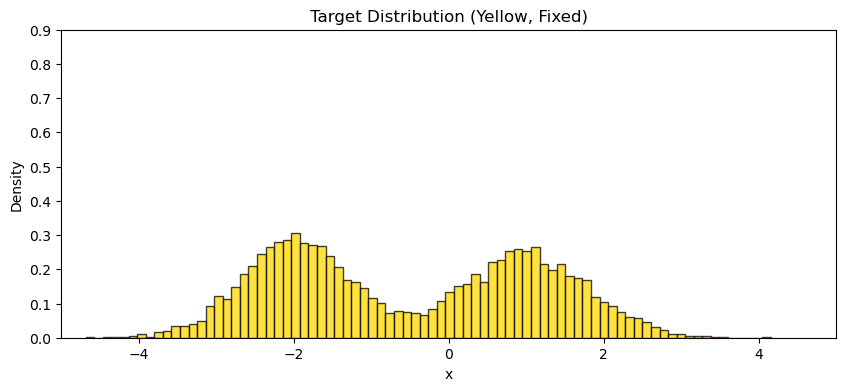

In [26]:
real_samples = sample_real_distribution(10000)

plt.figure(figsize=(10, 4))
plt.hist(real_samples, bins=80, density=True, alpha=0.75, color='gold', edgecolor='black')
plt.xlim(-5, 5)
plt.ylim(0, 0.9)
plt.title("Target Distribution (Yellow, Fixed)")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

In [27]:
def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def tanh_grad(a):
    # a = tanh(x)
    return 1 - a**2

def init_linear(in_dim, out_dim, scale=0.1):
    return {
        "W": np.random.randn(in_dim, out_dim) * scale,
        "b": np.zeros((1, out_dim))
    }

In [28]:
# 生成器 G: z(1维) -> hidden -> hidden -> x(1维)
G = {
    "l1": init_linear(1, 16, scale=0.20),
    "l2": init_linear(16, 16, scale=0.20),
    "l3": init_linear(16, 1, scale=0.05),
}

# 让生成器初始输出集中在 x≈4 附近，模拟图中右侧蓝色峰
G["l3"]["b"][:] = 4.0

# 判别器 D: x(1维) -> hidden -> hidden -> logit(1维)
D = {
    "l1": init_linear(1, 32, scale=0.30),
    "l2": init_linear(32, 32, scale=0.30),
    "l3": init_linear(32, 1, scale=0.30),
}

In [29]:
def linear_forward(x, layer):
    return x @ layer["W"] + layer["b"]

def generator_forward(z, G):
    h1 = linear_forward(z, G["l1"])
    a1 = np.tanh(h1)

    h2 = linear_forward(a1, G["l2"])
    a2 = np.tanh(h2)

    x_fake = linear_forward(a2, G["l3"])

    cache = {
        "z": z,
        "h1": h1, "a1": a1,
        "h2": h2, "a2": a2,
        "x_fake": x_fake
    }
    return x_fake, cache

def discriminator_forward(x, D):
    h1 = linear_forward(x, D["l1"])
    a1 = relu(h1)

    h2 = linear_forward(a1, D["l2"])
    a2 = relu(h2)

    logit = linear_forward(a2, D["l3"])
    prob = sigmoid(logit)

    cache = {
        "x": x,
        "h1": h1, "a1": a1,
        "h2": h2, "a2": a2,
        "logit": logit,
        "prob": prob
    }
    return prob, logit, cache

In [30]:
def discriminator_backward(cache, D, dlogit):
    """
    输入:
        dlogit = dL/d(logit)
    输出:
        dx: 对输入 x 的梯度
        grads: 对 D 参数的梯度
    """
    x  = cache["x"]
    h1 = cache["h1"]
    a1 = cache["a1"]
    h2 = cache["h2"]
    a2 = cache["a2"]

    # 第3层
    dW3 = a2.T @ dlogit
    db3 = np.sum(dlogit, axis=0, keepdims=True)
    da2 = dlogit @ D["l3"]["W"].T

    # ReLU2
    dh2 = da2 * relu_grad(h2)

    # 第2层
    dW2 = a1.T @ dh2
    db2 = np.sum(dh2, axis=0, keepdims=True)
    da1 = dh2 @ D["l2"]["W"].T

    # ReLU1
    dh1 = da1 * relu_grad(h1)

    # 第1层
    dW1 = x.T @ dh1
    db1 = np.sum(dh1, axis=0, keepdims=True)
    dx  = dh1 @ D["l1"]["W"].T

    grads = {
        "l1": {"W": dW1, "b": db1},
        "l2": {"W": dW2, "b": db2},
        "l3": {"W": dW3, "b": db3},
    }
    return dx, grads

In [31]:
def generator_backward(cache, G, dx_fake):
    """
    输入:
        dx_fake = dL/d(x_fake)
    输出:
        grads: 对 G 参数的梯度
    """
    z      = cache["z"]
    a1     = cache["a1"]
    a2     = cache["a2"]

    # 第3层
    dW3 = a2.T @ dx_fake
    db3 = np.sum(dx_fake, axis=0, keepdims=True)
    da2 = dx_fake @ G["l3"]["W"].T

    # tanh2
    dh2 = da2 * tanh_grad(a2)

    # 第2层
    dW2 = a1.T @ dh2
    db2 = np.sum(dh2, axis=0, keepdims=True)
    da1 = dh2 @ G["l2"]["W"].T

    # tanh1
    dh1 = da1 * tanh_grad(a1)

    # 第1层
    dW1 = z.T @ dh1
    db1 = np.sum(dh1, axis=0, keepdims=True)

    grads = {
        "l1": {"W": dW1, "b": db1},
        "l2": {"W": dW2, "b": db2},
        "l3": {"W": dW3, "b": db3},
    }
    return grads

In [32]:
def sgd_step(params, grads, lr):
    for k in params:
        params[k]["W"] -= lr * grads[k]["W"]
        params[k]["b"] -= lr * grads[k]["b"]

In [33]:
def discriminator_loss(p_real, p_fake, eps=1e-8):
    return -np.mean(np.log(p_real + eps) + np.log(1 - p_fake + eps))

def generator_loss(p_fake, eps=1e-8):
    # 非饱和形式: -log D(G(z))
    return -np.mean(np.log(p_fake + eps))

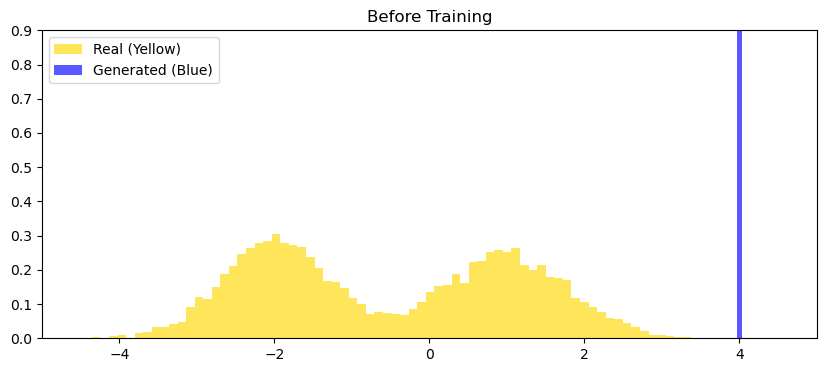

In [34]:
z0 = np.random.randn(5000, 1)
fake0, _ = generator_forward(z0, G)

plt.figure(figsize=(10, 4))
plt.hist(real_samples, bins=80, density=True, alpha=0.65, color='gold', label='Real (Yellow)')
plt.hist(fake0, bins=80, density=True, alpha=0.65, color='blue', label='Generated (Blue)')
plt.xlim(-5, 5)
plt.ylim(0, 0.9)
plt.title("Before Training")
plt.legend()
plt.show()

In [35]:
# 超参数
batch_size = 256
num_steps = 4000
lr_D = 0.002
lr_G = 0.0015
d_steps = 2   # 每轮多训练几次判别器，稳定一点

# 用于记录
history_D = []
history_G = []
snapshots = {}

snapshot_steps = [1, 50, 200, 500, 1000, 2000, 4000]

for step in range(1, num_steps + 1):

    # =========================
    # 1) 训练判别器 D
    # =========================
    for _ in range(d_steps):
        x_real = sample_real_distribution(batch_size)
        z = np.random.randn(batch_size, 1)
        x_fake, _ = generator_forward(z, G)

        p_real, logit_real, cache_real = discriminator_forward(x_real, D)
        p_fake, logit_fake, cache_fake = discriminator_forward(x_fake, D)

        # BCE 对 logit 的梯度:
        # y=1 -> p-1
        # y=0 -> p-0
        dlogit_real = (p_real - 1.0) / batch_size
        dlogit_fake = (p_fake - 0.0) / batch_size

        _, grads_real = discriminator_backward(cache_real, D, dlogit_real)
        _, grads_fake = discriminator_backward(cache_fake, D, dlogit_fake)

        grads_D = {}
        for k in D:
            grads_D[k] = {
                "W": grads_real[k]["W"] + grads_fake[k]["W"],
                "b": grads_real[k]["b"] + grads_fake[k]["b"]
            }

        sgd_step(D, grads_D, lr_D)

    # =========================
    # 2) 训练生成器 G
    # =========================
    z = np.random.randn(batch_size, 1)
    x_fake, cache_G = generator_forward(z, G)

    p_fake_for_G, logit_fake_for_G, cache_D_fake = discriminator_forward(x_fake, D)

    # 生成器使用非饱和损失:
    # L_G = -mean(log D(G(z)))
    # 对 logit 的梯度仍可写成 (p - 1)
    dlogit_for_G = (p_fake_for_G - 1.0) / batch_size

    dx_fake, _ = discriminator_backward(cache_D_fake, D, dlogit_for_G)
    grads_G = generator_backward(cache_G, G, dx_fake)

    sgd_step(G, grads_G, lr_G)

    # =========================
    # 3) 记录损失
    # =========================
    # 重新算一遍当前损失，便于观察
    x_real_eval = sample_real_distribution(batch_size)
    z_eval = np.random.randn(batch_size, 1)
    x_fake_eval, _ = generator_forward(z_eval, G)

    p_real_eval, _, _ = discriminator_forward(x_real_eval, D)
    p_fake_eval, _, _ = discriminator_forward(x_fake_eval, D)

    loss_D = discriminator_loss(p_real_eval, p_fake_eval)
    loss_G = generator_loss(p_fake_eval)

    history_D.append(loss_D)
    history_G.append(loss_G)

    # =========================
    # 4) 保存快照
    # =========================
    if step in snapshot_steps:
        z_vis = np.random.randn(5000, 1)
        fake_vis, _ = generator_forward(z_vis, G)
        snapshots[step] = fake_vis.ravel().copy()

    if step % 500 == 0:
        print(f"step={step:4d} | D_loss={loss_D:.4f} | G_loss={loss_G:.4f}")

step= 500 | D_loss=0.5476 | G_loss=2.3050
step=1000 | D_loss=0.4912 | G_loss=2.0373
step=1500 | D_loss=1.4110 | G_loss=0.3737
step=2000 | D_loss=0.9861 | G_loss=0.9353
step=2500 | D_loss=1.1243 | G_loss=0.9574
step=3000 | D_loss=1.3270 | G_loss=0.8370
step=3500 | D_loss=1.3132 | G_loss=0.7730
step=4000 | D_loss=1.3903 | G_loss=0.7360


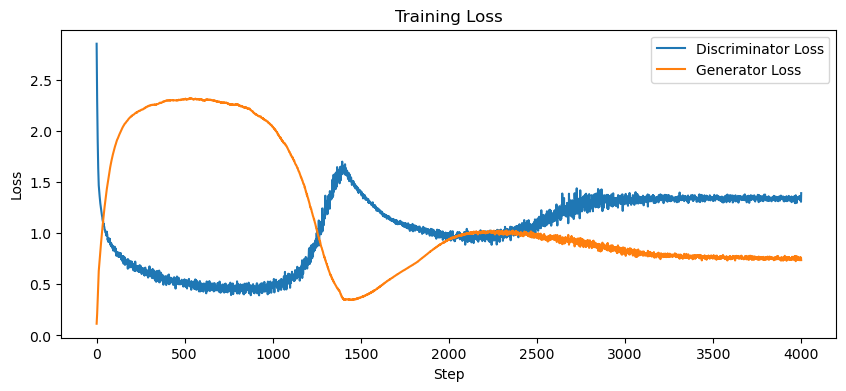

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(history_D, label="Discriminator Loss")
plt.plot(history_G, label="Generator Loss")
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

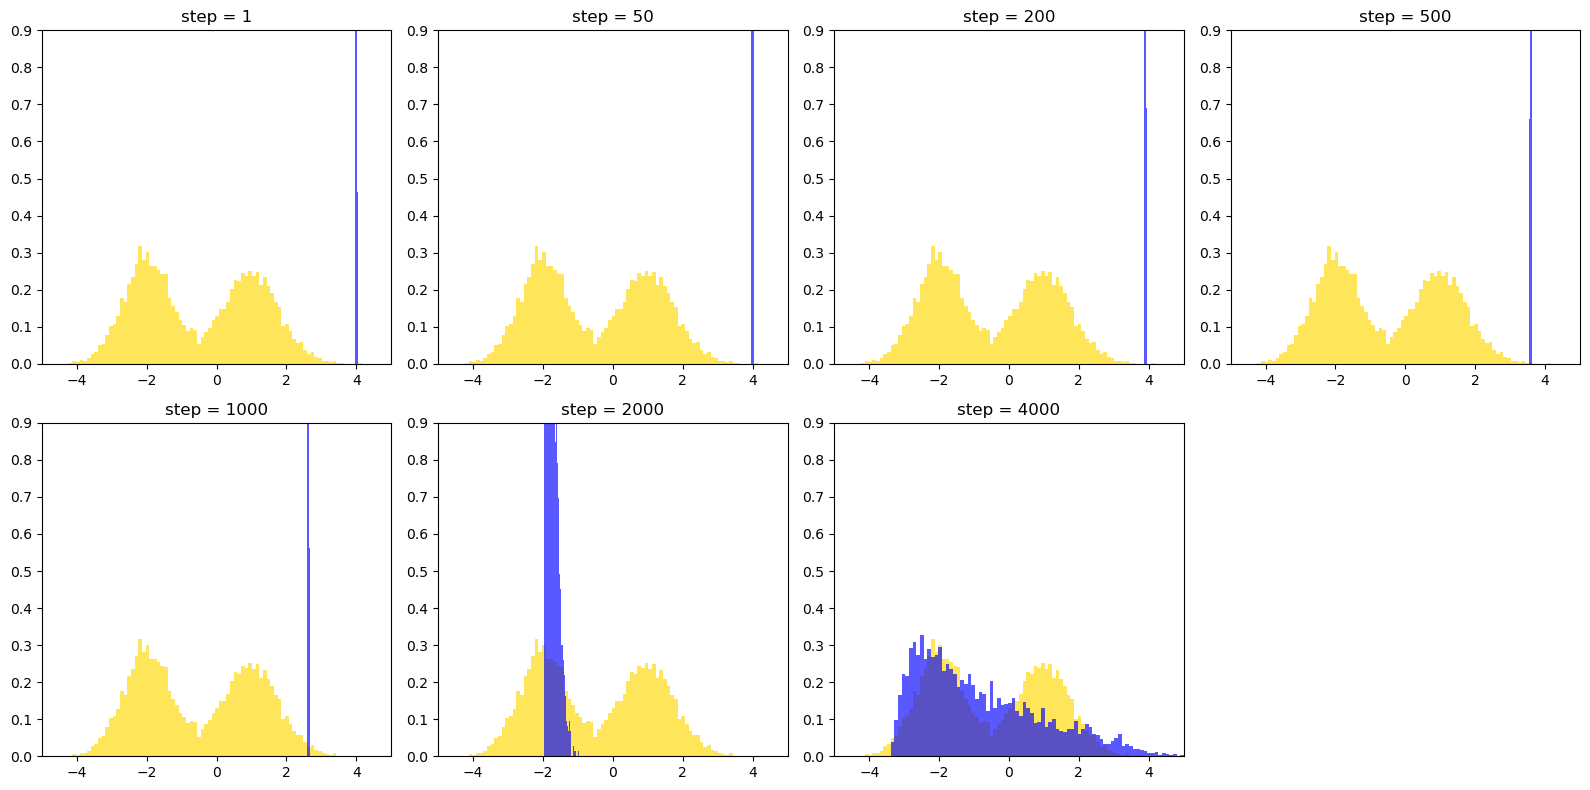

In [37]:
real_vis = sample_real_distribution(10000).ravel()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, step in enumerate(snapshot_steps):
    ax = axes[i]
    ax.hist(real_vis, bins=80, density=True, alpha=0.65, color='gold', label='Real')
    ax.hist(snapshots[step], bins=80, density=True, alpha=0.65, color='blue', label='Fake')
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, 0.9)
    ax.set_title(f"step = {step}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

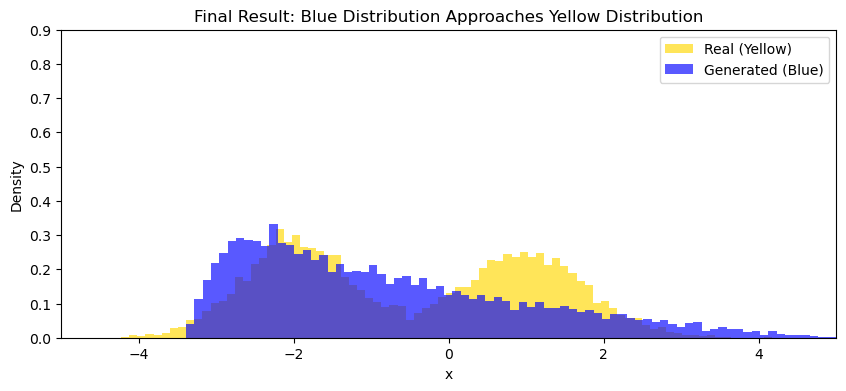

In [38]:
z_final = np.random.randn(10000, 1)
fake_final, _ = generator_forward(z_final, G)

plt.figure(figsize=(10, 4))
plt.hist(real_vis, bins=80, density=True, alpha=0.65, color='gold', label='Real (Yellow)')
plt.hist(fake_final, bins=80, density=True, alpha=0.65, color='blue', label='Generated (Blue)')
plt.xlim(-5, 5)
plt.ylim(0, 0.9)
plt.title("Final Result: Blue Distribution Approaches Yellow Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

In [39]:
# 为了动画，更密一些记录
animation_steps = list(range(1, 4001, 100))
animation_data = {}

# 重新初始化一个新 GAN，单独用于动画演示
np.random.seed(42)

G_anim = {
    "l1": init_linear(1, 16, scale=0.20),
    "l2": init_linear(16, 16, scale=0.20),
    "l3": init_linear(16, 1, scale=0.05),
}
G_anim["l3"]["b"][:] = 4.0

D_anim = {
    "l1": init_linear(1, 32, scale=0.30),
    "l2": init_linear(32, 32, scale=0.30),
    "l3": init_linear(32, 1, scale=0.30),
}

for step in range(1, 4001):
    for _ in range(2):
        x_real = sample_real_distribution(batch_size)
        z = np.random.randn(batch_size, 1)
        x_fake, _ = generator_forward(z, G_anim)

        p_real, _, cache_real = discriminator_forward(x_real, D_anim)
        p_fake, _, cache_fake = discriminator_forward(x_fake, D_anim)

        dlogit_real = (p_real - 1.0) / batch_size
        dlogit_fake = (p_fake - 0.0) / batch_size

        _, grads_real = discriminator_backward(cache_real, D_anim, dlogit_real)
        _, grads_fake = discriminator_backward(cache_fake, D_anim, dlogit_fake)

        grads_D = {}
        for k in D_anim:
            grads_D[k] = {
                "W": grads_real[k]["W"] + grads_fake[k]["W"],
                "b": grads_real[k]["b"] + grads_fake[k]["b"]
            }

        sgd_step(D_anim, grads_D, lr_D)

    z = np.random.randn(batch_size, 1)
    x_fake, cache_G = generator_forward(z, G_anim)
    p_fake, _, cache_D_fake = discriminator_forward(x_fake, D_anim)

    dlogit_for_G = (p_fake - 1.0) / batch_size
    dx_fake, _ = discriminator_backward(cache_D_fake, D_anim, dlogit_for_G)
    grads_G = generator_backward(cache_G, G_anim, dx_fake)
    sgd_step(G_anim, grads_G, lr_G)

    if step in animation_steps:
        z_vis = np.random.randn(5000, 1)
        fake_vis, _ = generator_forward(z_vis, G_anim)
        animation_data[step] = fake_vis.ravel().copy()

real_anim = sample_real_distribution(10000).ravel()

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))

def update(frame):
    ax.clear()
    step = animation_steps[frame]
    ax.hist(real_anim, bins=80, density=True, alpha=0.65, color='gold', label='Real')
    ax.hist(animation_data[step], bins=80, density=True, alpha=0.65, color='blue', label='Generated')
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, 0.9)
    ax.set_title(f"GAN Training Progress | step = {step}")
    ax.legend()

ani = FuncAnimation(fig, update, frames=len(animation_steps), interval=300)
plt.close(fig)
HTML(ani.to_jshtml())